**Sam Polyakov and Teagan Turner**

Spring 2026

CS 443: Bio-Inspired Machine Learning

Project 1: Hebbian Learning

#### Week 1: TensorFlow, Datasets, and Custom Neural Network Library

In [1]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=4)

# Automatically reload your external source code
%load_ext autoreload
%autoreload 2

## Task 4. Train `LinearDecoder` on MNIST and CIFAR-10

Woohoo! Your linear decoder is built and tested! Time for some fun! 😎

To train in a reasonable amount of time, upload your project code to CoCalc so that you can train on the GPU (*See detailed instructions and demos in lecture*).

*As noted on the website, if you have a higher-end Macbook with a Pro or Max chip and ≥ 16 GB of memory, you could probably run this workload on your computer if you would prefer. This is entirely optional and the cloud will almost certainly be faster than even the fastest Mac. Setting this up would just provide some extra convenience/flexibility. See the [macOS instructions](https://cs.colby.edu/courses/S26/cs443/software.html#tf) for setup.*

Run the cell below to make sure TensorFlow is running on the GPU.

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print('Running on the GPU')
else:
    print('NOT running on the GPU')

Running on the GPU


In [3]:
from image_datasets import get_dataset, train_val_split
from decoder_nets import LinearDecoder

### 4a. Train `LinearDecoder` on MNIST on the GPU

This will be a "hello world" test to make sure your `fit` method is working.

Write code in the cell below to load in MNIST

In [4]:
x_train, y_train, x_test, y_test = get_dataset('mnist', verbose=False)
x_train_split, y_train_split, x_val_split, y_val_split = train_val_split(x_train, y_train)

# KEEP ME
print(f'Your training set data have shape {x_train_split.shape} and they should be (54000, 784)')
print(f'Your training set labels have shape {y_train_split.shape} and they should be (54000,)')
print(f'Your val set data have shape {x_val_split.shape} and they should be (6000, 784)')
print(f'Your val set labels have shape {y_val_split.shape} and they should be (6000,)')
print(f'Your test set data have shape {x_test.shape} and they should be (10000, 784)')
print(f'Your test set labels have shape {y_test.shape} and they should be (10000,)')

I0000 00:00:1770900773.244401 13417462 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770900773.244917 13417462 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Your training set data have shape (54000, 784) and they should be (54000, 784)
Your training set labels have shape (54000,) and they should be (54000,)
Your val set data have shape (6000, 784) and they should be (6000, 784)
Your val set labels have shape (6000,) and they should be (6000,)
Your test set data have shape (10000, 784) and they should be (10000, 784)
Your test set labels have shape (10000,) and they should be (10000,)


Train `LinearDecoder` in the cell below on MNIST for `10` epochs and a batch size of `256`! Print out your accuracy on the test set when training is done.

The **entire** process of training and evaluating test accuracy should take no more than 30 seconds (*at most!*). If it is taking longer, seek help.

Your print outs should look something like:

```
---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 0/9, Training loss 0.533, Val loss 0.284, Val acc SURPRISE
Epoch 0 took: 2.0 secs
Epoch 1/9, Training loss 0.322, Val loss 0.257, Val acc SURPRISE
Epoch 1 took: 1.1 secs
Epoch 2/9, Training loss 0.299, Val loss 0.243, Val acc SURPRISE
Epoch 2 took: 1.1 secs
...
Epoch 9/9, Training loss 0.272, Val loss 0.234, Val acc SURPRISE
Epoch 9 took: 1.1 secs
Finished training after 10 epochs!
Linear Decoder MNIST Test accuracy: SURPRISE%
Training took: 12.55 secs
```

The val and test accuracy should be satisfyingly high — in the 90s.

In [5]:
# KEEP THIS SEED
tf.random.set_seed(0)

net = LinearDecoder(input_feats_shape=(784,), C=10)
net.compile()

train_loss_hist, val_loss_hist, val_acc_hist, e = net.fit(x_train_split, y_train_split, x_val = x_val_split, y_val = y_val_split, batch_size=256, max_epochs=10, print_every = 1)
test_acc, test_loss = net.evaluate(x_test, y_test)

print(f'Test accuracy: {test_acc}, Test loss: {test_loss}')

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/10 - train loss 0.5334 - val loss 0.2859 - val acc 0.9222
Epoch 1/10 took 3.49s
Epoch 2/10 - train loss 0.3216 - val loss 0.2586 - val acc 0.9288
Epoch 2/10 took 2.89s
Epoch 3/10 - train loss 0.2987 - val loss 0.2448 - val acc 0.9293
Epoch 3/10 took 2.71s
Epoch 4/10 - train loss 0.2841 - val loss 0.2389 - val acc 0.9325
Epoch 4/10 took 2.63s
Epoch 5/10 - train loss 0.2824 - val loss 0.2346 - val acc 0.9360
Epoch 5/10 took 2.74s
Epoch 6/10 - train loss 0.2703 - val loss 0.2350 - val acc 0.9343
Epoch 6/10 took 2.77s
Epoch 7/10 - train loss 0.2706 - val loss 0.2327 - val acc 0.9365
Epoch 7/10 took 2.64s
Epoch 8/10 - train loss 0.2651 - val loss 0.2328 - val acc 0.9350
Epoch 8/10 took 2.68s
Epoch 9/10 - train loss 0.2658 - val loss 0.2371 - val acc 0.9331
Epoch 9/10 took 2.63s
Epoch 10

### 4b. Train `LinearDecoder` on MNIST on the CPU

To appreciate the advantage for training deep networks on GPUs instead of your computer's CPU, copy-paste your code above that trains your `LinearDecoder` net on MNIST below. Instead of running it on CoCalc, run it locally on your computer. Be sure to print out the time per epoch.

*If the net takes >2 minutes per epoch on your computer, just train for one epoch then call it quits :)*

In [6]:
# KEEP THIS SEED
tf.random.set_seed(0)

gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print('Running on the GPU')
else:
    print('NOT running on the GPU')

net = LinearDecoder(input_feats_shape=(784,), C=10)
net.compile()

train_loss_hist, val_loss_hist, val_acc_hist, e = net.fit(x_train_split, y_train_split, x_val = x_val_split, y_val = y_val_split, batch_size=256, max_epochs=10, print_every = 1)
test_acc, test_loss = net.evaluate(x_test, y_test)

print(f'Test accuracy: {test_acc}, Test loss: {test_loss}')

NOT running on the GPU
---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/10 - train loss 0.5334 - val loss 0.2859 - val acc 0.9222
Epoch 1/10 took 1.07s
Epoch 2/10 - train loss 0.3216 - val loss 0.2586 - val acc 0.9288
Epoch 2/10 took 1.06s
Epoch 3/10 - train loss 0.2987 - val loss 0.2448 - val acc 0.9293
Epoch 3/10 took 0.96s
Epoch 4/10 - train loss 0.2841 - val loss 0.2389 - val acc 0.9325
Epoch 4/10 took 1.04s
Epoch 5/10 - train loss 0.2824 - val loss 0.2346 - val acc 0.9360
Epoch 5/10 took 0.99s
Epoch 6/10 - train loss 0.2703 - val loss 0.2350 - val acc 0.9343
Epoch 6/10 took 1.04s
Epoch 7/10 - train loss 0.2706 - val loss 0.2327 - val acc 0.9365
Epoch 7/10 took 0.98s
Epoch 8/10 - train loss 0.2651 - val loss 0.2328 - val acc 0.9350
Epoch 8/10 took 0.94s
Epoch 9/10 - train loss 0.2658 - val loss 0.2371 - val acc 0.9331
Epoch 9

### 4c. Questions

**Question 1:** Approximately how long did it take for 1 epoch of training with and without the GPU. Compute the relative compute time (`gpu_time_per_epoch`/`cpu_time_per_epoch`). What do you think?

**Answer 1:** Ignoring this per email instructions.

### 4d. Train `LinearDecoder` on CIFAR-10

Now let's train on CIFAR-10. Run this (*and all subsequent large training sessions*) on CoCalc/the GPU 😊

Write code in the cell below to load in CIFAR-10 with global RGB normalization.

In [6]:
x_train, y_train, x_test, y_test = get_dataset('cifar10', verbose=False)
x_train_split, y_train_split, x_val_split, y_val_split = train_val_split(x_train, y_train)

# KEEP ME
print(f'Your training set data have shape {x_train_split.shape} and they should be (45000, 3072)')
print(f'Your training set labels have shape {y_train_split.shape} and they should be (45000,)')
print(f'Your val set data have shape {x_val_split.shape} and they should be (5000, 3072)')
print(f'Your val set labels have shape {y_val_split.shape} and they should be (5000,)')
print(f'Your test set data have shape {x_test.shape} and they should be (10000, 3072)')
print(f'Your test set labels have shape {y_test.shape} and they should be (10000,)')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Your training set data have shape (45000, 3072) and they should be (45000, 3072)
Your training set labels have shape (45000,) and they should be (45000,)
Your val set data have shape (5000, 3072) and they should be (5000, 3072)
Your val set labels have shape (5000,) and they should be (5000,)
Your test set data have shape (10000, 3072) and they should be (10000, 3072)
Your test set labels have shape (10000,) and they should be (10000,)


Train `LinearDecoder` on CIFAR-10 in the cell below for `10` epochs and use a batch size of `256`.

*You should anticipate no more than ~1 min of total training time on the GPU. If this is far off, please seek help.*

Plot the training and val loss over epochs. Put test acc in the title. *If everything is working, your training and validation loss should steadily decrease then start to plateau by the end of training.*

In [8]:
# KEEP THIS SEED
tf.random.set_seed(0)

net = LinearDecoder(input_feats_shape=(3072,), C=10)
net.compile()

train_loss_hist, val_loss_hist, val_acc_hist, e = net.fit(x_train_split, y_train_split, x_val = x_val_split, y_val = y_val_split, batch_size=256, max_epochs=10, print_every = 1)
test_acc, test_loss = net.evaluate(x_test, y_test)

print(f'Test accuracy: {test_acc}, Test loss: {test_loss}')


---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/10 - train loss 1.8538 - val loss 1.8523 - val acc 0.3718
Epoch 1/10 took 3.54s
Epoch 2/10 - train loss 1.7669 - val loss 1.8173 - val acc 0.3802
Epoch 2/10 took 2.60s
Epoch 3/10 - train loss 1.7460 - val loss 1.8591 - val acc 0.3622
Epoch 3/10 took 2.34s
Epoch 4/10 - train loss 1.7334 - val loss 1.8228 - val acc 0.3834
Epoch 4/10 took 2.79s
Epoch 5/10 - train loss 1.7081 - val loss 1.8332 - val acc 0.3794
Epoch 5/10 took 2.54s
Epoch 6/10 - train loss 1.7279 - val loss 1.8395 - val acc 0.3740
Epoch 6/10 took 2.58s
Epoch 7/10 - train loss 1.7069 - val loss 1.8412 - val acc 0.3642
Epoch 7/10 took 2.45s
Epoch 8/10 - train loss 1.6998 - val loss 1.8280 - val acc 0.3794
Epoch 8/10 took 2.34s
Epoch 9/10 - train loss 1.6938 - val loss 1.8252 - val acc 0.3776
Epoch 9/10 took 2.36s
Epoch 10

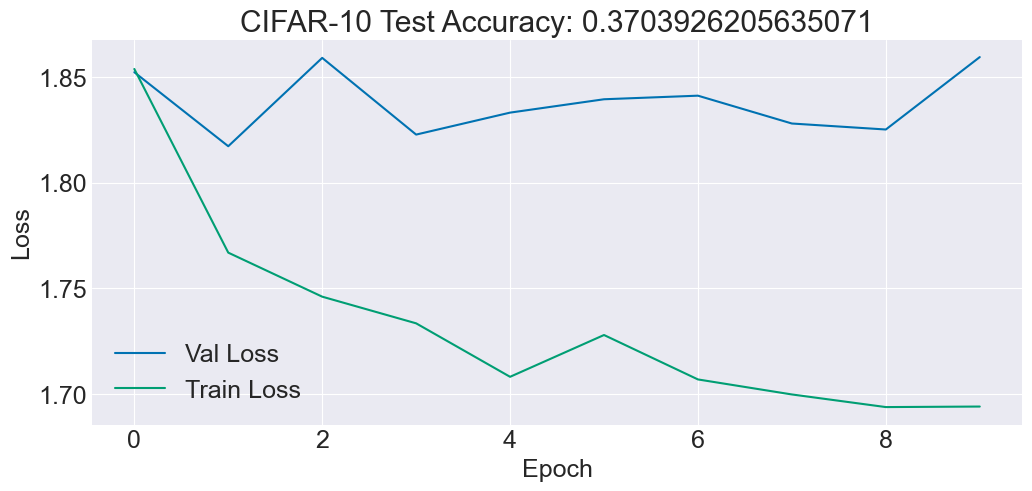

In [10]:
plt.figure(figsize=(12, 5))
plt.title(f'CIFAR-10 Test Accuracy: {test_acc}')
plt.plot(val_loss_hist, label='Val Loss')
plt.plot(train_loss_hist, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 4e. Experiment: Effect of batch size on runtime and accuracy

To develop your intuition about how the choice of batch size generally affects runtime and accuracy on a dataset like CIFAR-10, run an experiment in which fresh `LinearDecoder` nets are trained for `10` epochs with one of the following batch sizes:<br/>
`[128, 256, 512, 1024, 2048]`. After each training run, record the test accuracy and runtime.

Create two plots:
1. The test accuracy (y axis) as a function of the batch size (x axis). There should be 5 markers joined by a single curve.
2. The runtime (y axis) as a function of the batch size (x axis). There should be 5 markers joined by a single curve.

**Note:**
- Your `fit` method prints the runtime per epoch, but in this task you should record the total runtime over training and prediction. (in seconds). To do this, it may make sense to use the time module to record the total time in the notebook cell below.
- You should be running this on the GPU!

In [12]:
# KEEP THIS SEED
tf.random.set_seed(0)
batch_sizes = [128, 256, 512, 1024, 2048]

test_accs = []
runtimes = []

for batch_size in batch_sizes:
    print(f'\nBatch Size: {batch_size}')
    net = LinearDecoder(input_feats_shape=(3072,), C=10)
    net.compile()
    start = time.time()
    train_loss_hist, val_loss_hist, val_acc_hist, e = net.fit(x_train_split, y_train_split, x_val = x_val_split, y_val = y_val_split, batch_size=batch_size, max_epochs=10)
    end = time.time()
    runtime = end - start
    test_acc, test_loss = net.evaluate(x_test, y_test)
    print(f'Test accuracy: {test_acc}, Runtime: {runtime} seconds')
    runtimes.append(runtime)
    test_accs.append(test_acc)




Batch Size: 128
---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 10/10 - train loss 1.7326 - val loss 1.9233 - val acc 0.3590
Epoch 10/10 took 4.30s
Finished training after 10 epochs!
Test accuracy: 0.3643830120563507, Runtime: 43.80534386634827 seconds

Batch Size: 256
---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 10/10 - train loss 1.6940 - val loss 1.8593 - val acc 0.3740
Epoch 10/10 took 2.51s
Finished training after 10 epochs!
Test accuracy: 0.37079328298568726, Runtime: 26.90866780281067 seconds

Batch Size: 512
---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
----------------------------------

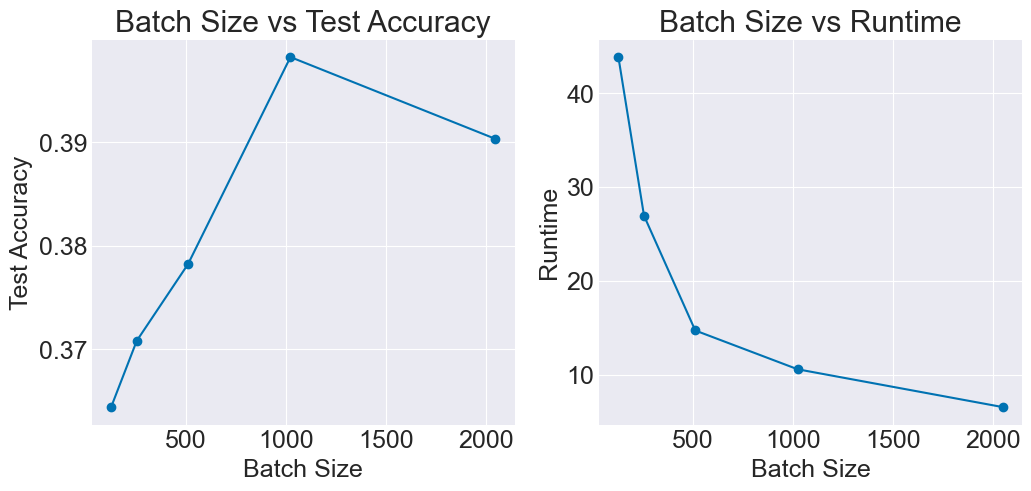

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(batch_sizes, test_accs, marker='o')
ax[0].set_ylabel('Test Accuracy')
ax[0].set_xlabel('Batch Size')
ax[0].set_title('Batch Size vs Test Accuracy')

ax[1].plot(batch_sizes, runtimes, marker='o')
ax[1].set_ylabel('Runtime')
ax[1].set_xlabel('Batch Size')
ax[1].set_title('Batch Size vs Runtime')
plt.show()

### 4f. Questions

**Question 2:** What do the plots suggest to you about the relationship between batch size and accuracy? Please be specific,citing evidence from your plots.

**Question 3:** Do you find this relationship surprising? Why or why not?

**Answer 2:** The plots suggest that as batch size increases, the test accuracy increases to a certain point and then begins to decrease. In ours, a batch size of 1024 resulted in the highest test accuracy, and then it decreased after that. This indicates, for 10 epochs, that the optimal batch size is 1024. The smaller batches have lots of updates obviously but aren't as precise/don't average enough, but 2048 essentially underfits because it takes too much of an average of the gradients so our sweet spot is 1024.

**Answer 3:** I don't find it that surprising. I was a little bit surprised that we didn't reach a higher accuracy with a batch size of 512, but it makes sense that 1024 would be a better accuracy because it is averaging more gradients and getting a better estimate. 2048 being worse also makes sense as I mentioned because it is averaging too much. The runtime also makes sense since it takes fewer updates per epoch.